In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import models, layers, regularizers

In [2]:
config = tf.compat.v1.ConfigProto(gpu_options =
                         tf.compat.v1.GPUOptions(per_process_gpu_memory_fraction=1)
)

config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)
tf.compat.v1.keras.backend.set_session(session)

physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))


Num GPUs Available:  1


In [3]:
data_train = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_VIS_PCA_train.npy', allow_pickle= True)
train_labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_Ripeness_VIS_train_labels.npy', allow_pickle= True)

data_val = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_VIS_PCA_val.npy', allow_pickle= True)
val_labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_Ripeness_VIS_val_labels.npy', allow_pickle= True)

data_test = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_VIS_PCA_test.npy', allow_pickle= True)
test_labels = np.load(r'C:\Users\rafin\Desktop\HSIC\Ripeness\Datasets\CNN_Datasets\Kiwi_VIS\PCA\Kiwi_Ripeness_VIS_test_labels.npy', allow_pickle= True)

data_train.shape, train_labels.shape, data_val.shape, val_labels.shape, data_test.shape, test_labels.shape

((1390, 32, 32, 142),
 (1390,),
 (230, 32, 32, 142),
 (230,),
 (240, 32, 32, 142),
 (240,))

In [4]:
# Compute mean and std from training data (per-channel normalization)
mean = data_train.mean(axis=(0, 1, 2), keepdims=True)
std_dev = data_train.std(axis=(0, 1, 2), keepdims=True)

# Normalize all datasets using training statistics
data_train = (data_train - mean) / std_dev
data_val = (data_val - mean) / std_dev
data_test = (data_test - mean) / std_dev

# Verify shapes
print("Shapes after normalization:")
print("Train:", data_train.shape, "Labels:", train_labels.shape)
print("Val:", data_val.shape, "Labels:", val_labels.shape)
print("Test:", data_test.shape, "Labels:", test_labels.shape)

Shapes after normalization:
Train: (1390, 32, 32, 142) Labels: (1390,)
Val: (230, 32, 32, 142) Labels: (230,)
Test: (240, 32, 32, 142) Labels: (240,)


In [5]:
le = LabelEncoder()

y_train = le.fit_transform(train_labels)
y_val = le.transform(val_labels)
y_test = le.transform(test_labels)

print("Class mapping:", le.classes_)

Class mapping: ['Overripe' 'Perfect' 'Unripe']


In [6]:
for class_name, encoded_label in zip(le.classes_, range(len(le.classes_))):
    
    print(f"Original: '{class_name}' \t-> Encoded: {encoded_label}")

Original: 'Overripe' 	-> Encoded: 0
Original: 'Perfect' 	-> Encoded: 1
Original: 'Unripe' 	-> Encoded: 2


In [7]:
# Add channel dimension to data
data_train = data_train[..., np.newaxis]
data_val = data_val[..., np.newaxis]
data_test = data_test[..., np.newaxis]

data_train.shape ,data_val.shape, data_test.shape

((1390, 32, 32, 142, 1), (230, 32, 32, 142, 1), (240, 32, 32, 142, 1))

In [8]:
def augment_data(sample, label):
    
    # Ensure both are the same type
    random_scale = tf.cast(tf.random.uniform([], 0.9, 1.1), dtype=sample.dtype)
    sample = sample * random_scale  # Random scale between 0.9 and 1.1
    
    return sample, label

In [9]:
# Convert all data to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((data_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((data_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((data_test, y_test))

# Configure datasets
batch_size = 4

train_dataset = train_dataset.shuffle(buffer_size=100).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [10]:
#tf.random.set_seed(1234)

input_shape = (32, 32, 142, 1)

model = models.Sequential([
    
    #1st Conv Layer
    layers.Conv3D(32, kernel_size=(3, 3, 3), strides=(1, 1, 1), activation='relu',
                  kernel_regularizer=regularizers.l2(0.01), input_shape=input_shape),
    layers.AveragePooling3D(pool_size=(2, 2, 2)),
  
     
    #2nd Conv Layer
    layers.Conv3D(64, kernel_size=(3, 3, 3), strides=(1, 1, 1), activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),

    #3rd Conv Layer
    layers.Conv3D(128, kernel_size=(3, 3, 3), strides=(1, 1, 1), activation='relu',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.AveragePooling3D(pool_size=(2, 2, 2)),

    layers.Flatten(),
    
    #1st FC layer
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),  # Dropout with a rate of 0.5

    #2nd FC layer
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 30, 30, 140, 32)   896       
                                                                 
 average_pooling3d (AverageP  (None, 15, 15, 70, 32)   0         
 ooling3D)                                                       
                                                                 
 conv3d_1 (Conv3D)           (None, 13, 13, 68, 64)    55360     
                                                                 
 conv3d_2 (Conv3D)           (None, 11, 11, 66, 128)   221312    
                                                                 
 average_pooling3d_1 (Averag  (None, 5, 5, 33, 128)    0         
 ePooling3D)                                                     
                                                                 
 flatten (Flatten)           (None, 105600)            0

In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define the callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = '3DCNN_Kiwi__VIS_PCA_model.h5',            # Path to save the best model
    monitor = 'val_accuracy',                   # Metric to monitor
    save_best_only = True,                 # Save only the best model
    save_weights_only = False,             # Save the entire model (architecture + weights)
    mode = 'max',                          # Mode 'max' because we want to maximize accuracy
    verbose = 1
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor = 'loss',
    patience = 15,
    restore_best_weights = True
)

# Train the model with the callbacks
history = model.fit(
    train_dataset,
    epochs = 100,
    validation_data = val_dataset,
    callbacks = [checkpoint_callback, early_stopping_callback]
)

Epoch 1/100
348/348 [==============================] - ETA: 0s - loss: 1.0611 - accuracy: 0.8705
Epoch 1: val_accuracy improved from -inf to 0.30435, saving model to 3DCNN_Kiwi__VIS_PCA_model.h5
348/348 [==============================] - 25s 48ms/step - loss: 1.0611 - accuracy: 0.8705 - val_loss: 16.7142 - val_accuracy: 0.3043
Epoch 2/100
347/348 [============================>.] - ETA: 0s - loss: 1.4162 - accuracy: 0.5677
Epoch 2: val_accuracy did not improve from 0.30435
348/348 [==============================] - 16s 45ms/step - loss: 1.4154 - accuracy: 0.5683 - val_loss: 1.2080 - val_accuracy: 0.3043
Epoch 3/100
347/348 [============================>.] - ETA: 0s - loss: 1.1012 - accuracy: 0.4157
Epoch 3: val_accuracy did not improve from 0.30435
348/348 [==============================] - 16s 45ms/step - loss: 1.1008 - accuracy: 0.4165 - val_loss: 1.1903 - val_accuracy: 0.3043
Epoch 4/100
347/348 [============================>.] - ETA: 0s - loss: 1.1529 - accuracy: 0.3415
Epoch 4: val

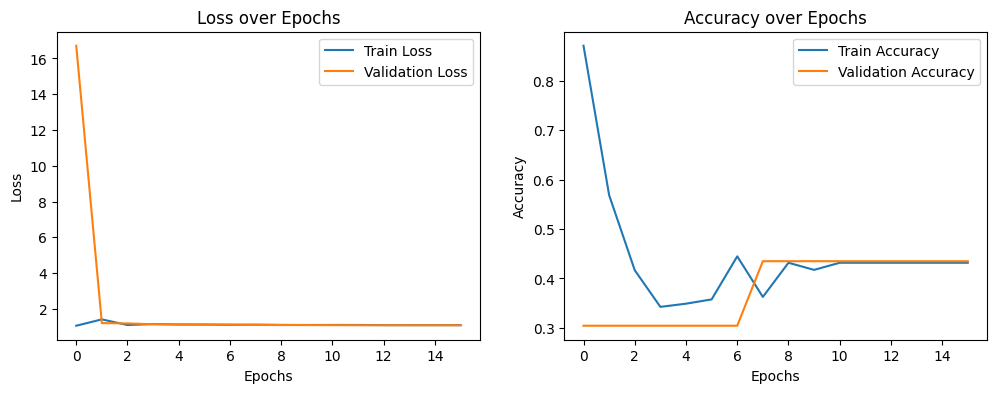

In [12]:
# Plot training & validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [13]:
# Get true labels and predictions
test_labels = np.concatenate([y for x, y in test_dataset], axis=0)
predictions = np.argmax(model.predict(test_dataset), axis=-1)

60/60 [==============================] - 1s 16ms/step


In [14]:
# Classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.00      0.00      0.00       100
           2       0.33      1.00      0.50        80

    accuracy                           0.33       240
   macro avg       0.11      0.33      0.17       240
weighted avg       0.11      0.33      0.17       240



c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

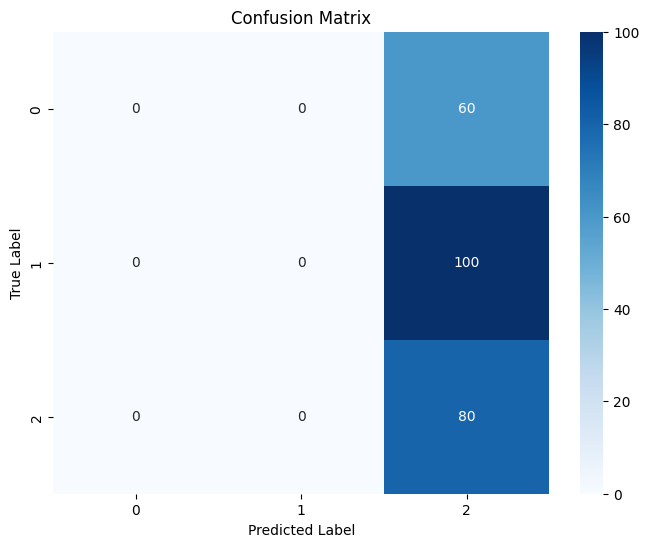

In [15]:
# Confusion matrix
conf_matrix = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[str(i) for i in range(3)], yticklabels=[str(i) for i in range(3)])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()